In [1]:
import os
import sys

sys.path.append(os.path.join(os.getcwd(), "src"))

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances

from datasets import Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

dataset_key = "netbeans_pretrain_10"
run_name = "bge-base-netbeans_10"
generate_dataset = False
batch_size = 16
eval_size = 1000
num_frames = 10
num_train_pairs = 5
num_test_pairs = 1
# trim_length = 0
frame_freq = {}

test_dataset = Dataset.load_from_disk(f"datasets/{dataset_key}_eval")
model = SentenceTransformer("BAAI/bge-base-en")
model_after = SentenceTransformer(f"models/{run_name}/final")

print(f"Model sequence length: {model.max_seq_length}")

# Find model size in CUDA
print(f"Model size: {torch.cuda.memory_allocated() / 1024 ** 3:.2f} GB")

Using device: cuda
Model sequence length: 512
Model size: 1.23 GB


In [4]:
def visualize_distances_before_after(
    test_dataset, model_before, model_after, num_samples=10, metric="cosine"
):
    samples = test_dataset.select(range(num_samples))

    anchor_positive_distances_before = []
    anchor_negative_distances_before = []
    anchor_positive_distances_after = []
    anchor_negative_distances_after = []

    # Compute distances for each triplet
    for sample in samples:
        anchor, positive, negative = (
            sample["anchor"],
            sample["positive"],
            sample["negative"],
        )

        # Embeddings before training
        emb_anchor_before = model_before.encode(anchor)
        emb_positive_before = model_before.encode(positive)
        emb_negative_before = model_before.encode(negative)

        # Embeddings after training
        emb_anchor_after = model_after.encode(anchor)
        emb_positive_after = model_after.encode(positive)
        emb_negative_after = model_after.encode(negative)

        # Compute distances
        if metric == "cosine":
            anchor_positive_distances_before.append(
                cosine_distances([emb_anchor_before], [emb_positive_before])[0][0]
            )
            anchor_negative_distances_before.append(
                cosine_distances([emb_anchor_before], [emb_negative_before])[0][0]
            )
            anchor_positive_distances_after.append(
                cosine_distances([emb_anchor_after], [emb_positive_after])[0][0]
            )
            anchor_negative_distances_after.append(
                cosine_distances([emb_anchor_after], [emb_negative_after])[0][0]
            )
        elif metric == "euclidean":
            anchor_positive_distances_before.append(
                np.linalg.norm(emb_anchor_before - emb_positive_before)
            )
            anchor_negative_distances_before.append(
                np.linalg.norm(emb_anchor_before - emb_negative_before)
            )
            anchor_positive_distances_after.append(
                np.linalg.norm(emb_anchor_after - emb_positive_after)
            )
            anchor_negative_distances_after.append(
                np.linalg.norm(emb_anchor_after - emb_negative_after)
            )

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # Plot distances before training
    axes[0].scatter(
        range(num_samples),
        anchor_positive_distances_before,
        color="green",
        label="Anchor-Positive",
        alpha=0.7,
    )
    axes[0].scatter(
        range(num_samples),
        anchor_negative_distances_before,
        color="red",
        label="Anchor-Negative",
        alpha=0.7,
    )
    axes[0].axhline(y=0, color='blue', linestyle='--', linewidth=2, label='Anchor')
    axes[0].set_title("Distances Before Training")
    axes[0].set_ylabel(f"{metric.capitalize()} Distance")
    axes[0].grid()

    # Plot distances after training
    axes[1].scatter(
        range(num_samples),
        anchor_positive_distances_after,
        color="green",
        label="Anchor-Positive",
        alpha=0.7,
    )
    axes[1].scatter(
        range(num_samples),
        anchor_negative_distances_after,
        color="red",
        label="Anchor-Negative",
        alpha=0.7,
    )
    axes[1].axhline(y=0, color='blue', linestyle='--', linewidth=2, label='Anchor')
    axes[1].set_title("Distances After Training")
    axes[1].grid()

    # Create a single legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3)

    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.savefig("distance_plot_base.png")
    plt.show()

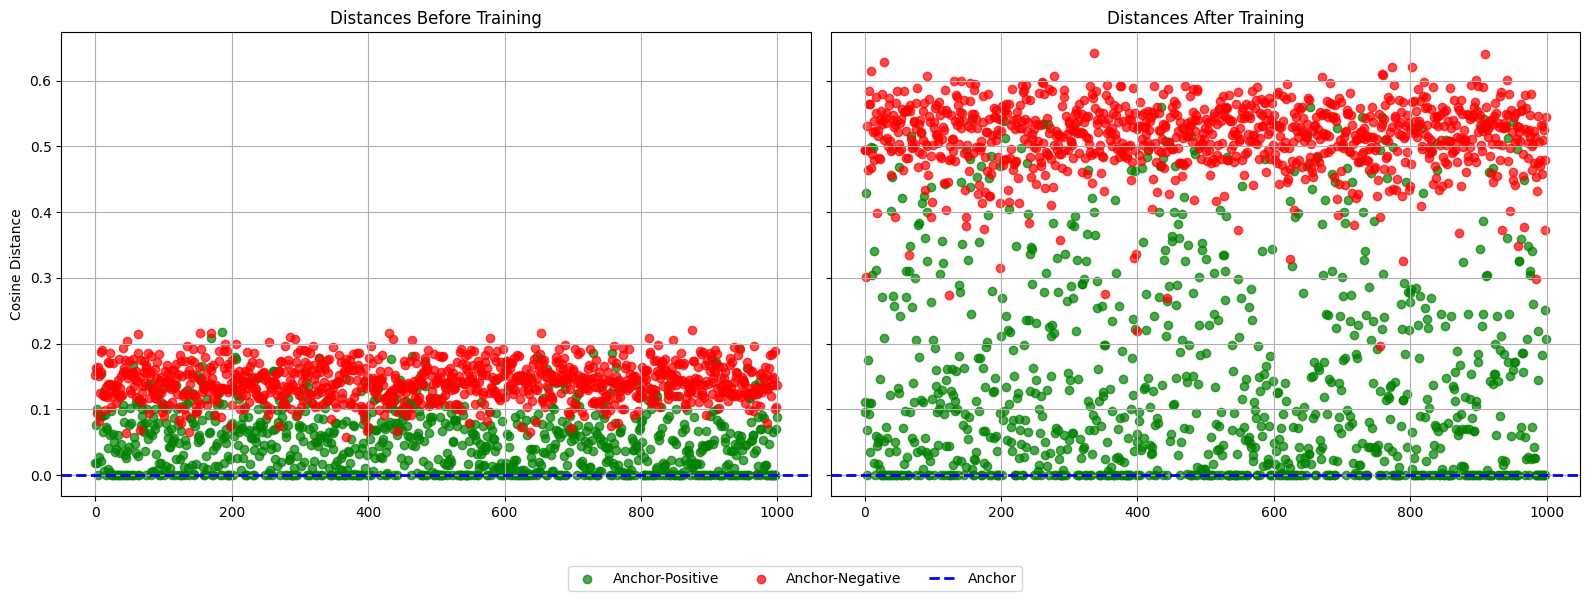

In [5]:
visualize_distances_before_after(test_dataset, model, model_after, num_samples=1000)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import random

def generate_tsne_plot(test_dataset, model, num_samples=10, random_seed=42):
    # Extract the first 'num_samples' test samples randomly
    random.seed(random_seed)
    random_indices = random.sample(range(len(test_dataset)), num_samples)
    raw_samples = test_dataset.select(random_indices)
    print("Before:", len(raw_samples))

    samples = [sample for sample in raw_samples if sample["anchor"] != sample["positive"]]
    print("After:", len(samples))

    # Prepare lists to hold embeddings and labels for anchor, positive, and negative samples
    embeddings = []
    labels = []  # 0 for anchor, 1 for positive, 2 for negative
    pairs = []  # To store connections for anchors to positive and negative points
    colors = ["blue", "green", "red"]  # Colors for anchor, positive, negative

    for i in range(len(samples)):
        # Get anchor, positive, and negative sentences
        anchor_sentence = samples[i]["anchor"]
        positive_sentence = samples[i]["positive"]
        negative_sentence = samples[i]["negative"]

        # Get embeddings for anchor, positive, and negative
        anchor_embedding = model.encode([anchor_sentence])[0]
        positive_embedding = model.encode([positive_sentence])[0]
        negative_embedding = model.encode([negative_sentence])[0]

        # Append embeddings and labels
        embeddings.append(anchor_embedding)
        labels.append(0)  # Anchor

        embeddings.append(positive_embedding)
        labels.append(1)  # Positive

        embeddings.append(negative_embedding)
        labels.append(2)  # Negative

        # Store pairs (anchor, positive) and (anchor, negative)
        pairs.append((len(embeddings) - 3, len(embeddings) - 2))  # (anchor, positive)
        pairs.append((len(embeddings) - 3, len(embeddings) - 1))  # (anchor, negative)

    embeddings = np.array(embeddings)
    labels = np.array(labels)

    # Apply t-SNE to reduce dimensionality to 2D for visualization
    tsne = TSNE(n_components=2, random_state=42, perplexity=len(samples))
    tsne_results = tsne.fit_transform(embeddings)

    # Plot the t-SNE results
    plt.figure(figsize=(6, 4))

    # Plot each type of sample with different colors
    for i, color in enumerate(colors):
        plt.scatter(
            tsne_results[labels == i, 0],
            tsne_results[labels == i, 1],
            c=color,
            label=["Anchor", "Positive", "Negative"][i],
            alpha=0.7,
        )

    # Add connections (lines) for each anchor to its positive and negative samples
    for anchor_idx, target_idx in pairs:
        plt.plot(
            [tsne_results[anchor_idx, 0], tsne_results[target_idx, 0]],
            [tsne_results[anchor_idx, 1], tsne_results[target_idx, 1]],
            color="gray",
            alpha=0.5,
            linestyle="--",
        )

    # Add sequential labels only to anchor points
    anchor_indices = np.where(labels == 0)[0]  # Indices of anchor points
    for i, idx in enumerate(anchor_indices):  # Sequential numbering for anchors only
        plt.text(
            tsne_results[idx, 0],
            tsne_results[idx, 1],
            str(i + 1),  # Start numbering from 1
            fontsize=9,
            color="black",
            weight="bold",
        )

    plt.title("t-SNE Visualization of Anchor, Positive, and Negative Samples")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend()
    plt.savefig("tsne_plot_with_connections.png")
    plt.show()


Before: 5
After: 5


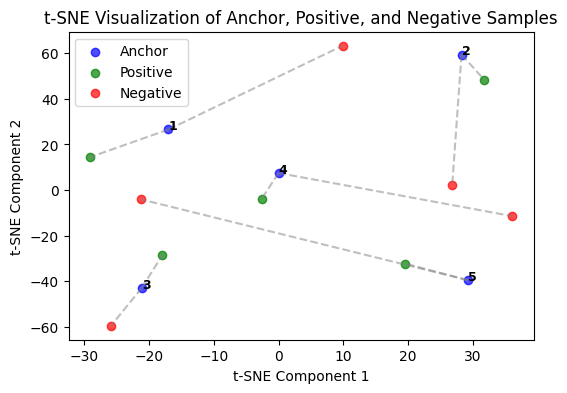

Before: 5
After: 5


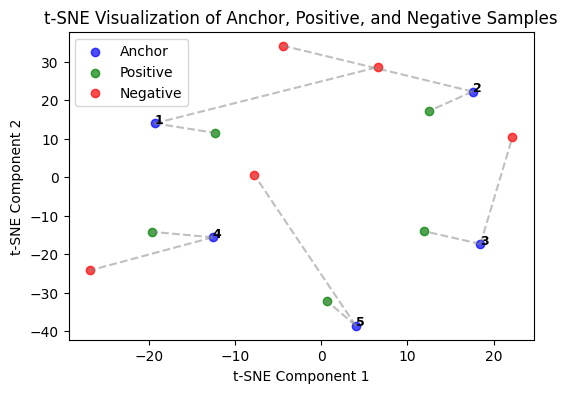

In [42]:
n_s = 5
seed = 2252
generate_tsne_plot(test_dataset, model, num_samples=n_s, random_seed=seed)
generate_tsne_plot(test_dataset, model_after, num_samples=n_s, random_seed=seed)

In [ ]:
generate_tsne_plot(test_dataset, model, num_samples=n_s, random_seed=seed)
generate_tsne_plot(test_dataset, model_after, num_samples=n_s, random_seed=seed)